In [2]:
# Step 1: Imports

import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import os
from dotenv import load_dotenv

In [3]:
# Step 2: Load .env FIRST

load_dotenv()

DB_HOST = os.getenv("DB_HOST")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_NAME = os.getenv("DB_NAME")

In [4]:
# Step 3: Encode Password

encoded_password = quote_plus(DB_PASSWORD)

In [5]:
# Step 4: Create Engine (USE ENCODED PASSWORD)

engine = create_engine(
    f"mysql+mysqlconnector://{DB_USER}:{encoded_password}@{DB_HOST}/{DB_NAME}"
)

In [6]:
# Step 5: Load Data

query = "SELECT * FROM customers"
df = pd.read_sql(query, engine)

df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [8]:
df = df.dropna()

In [9]:
df = df.drop_duplicates()

In [10]:
binary_cols = [
    "Partner", "Dependents", "PhoneService",
    "PaperlessBilling", "Churn"
]

for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

In [11]:
df["gender"] = df["gender"].map({"Male": 1, "Female": 0})

In [12]:
df["Churn"].value_counts(normalize=True) * 100

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64

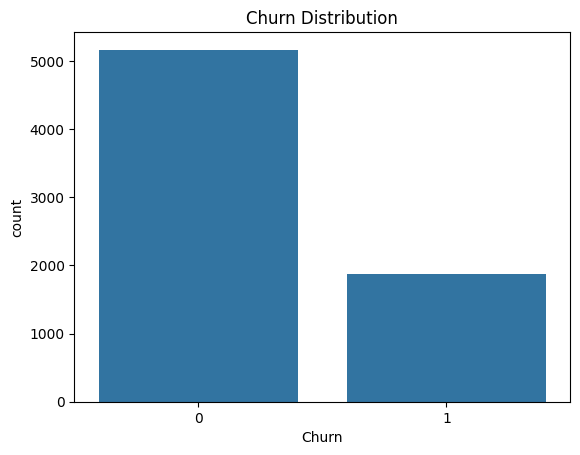

In [17]:
# Churn Count Visualization

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

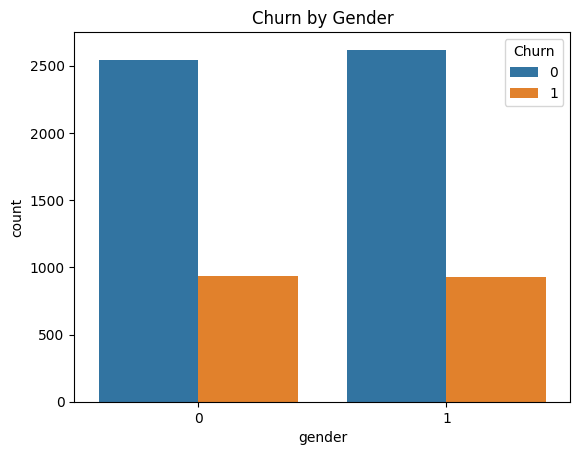

In [18]:
# Churn by Gender

sns.countplot(x="gender", hue="Churn", data=df)
plt.title("Churn by Gender")
plt.show()

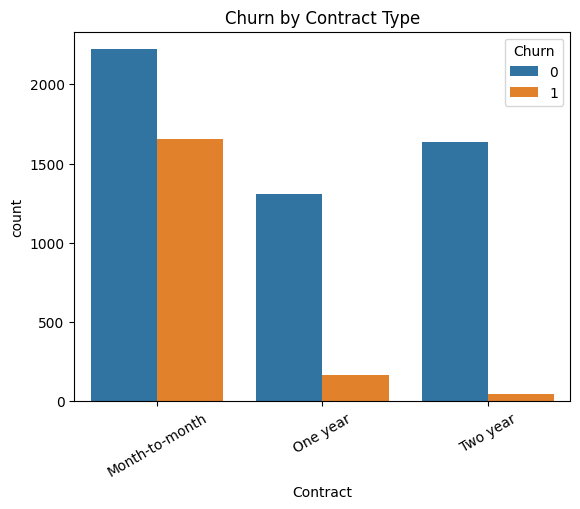

In [19]:
# Churn by Contract Type

sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=30)
plt.show()

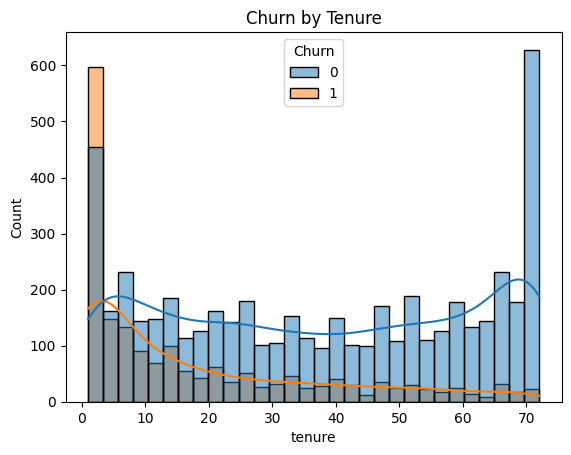

In [20]:
# Churn by Tenure

sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True)
plt.title("Churn by Tenure")
plt.show()

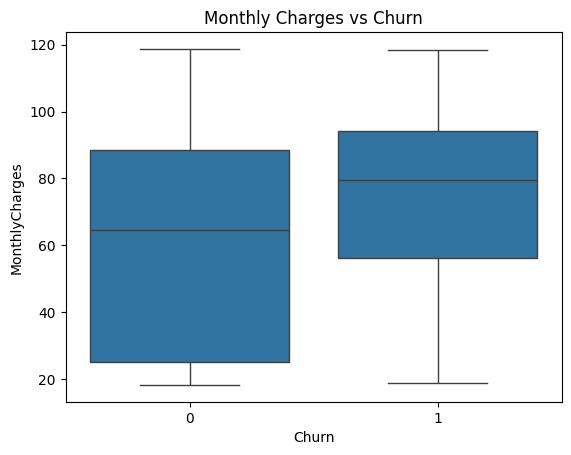

In [21]:
# Churn by Monthly Charges

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

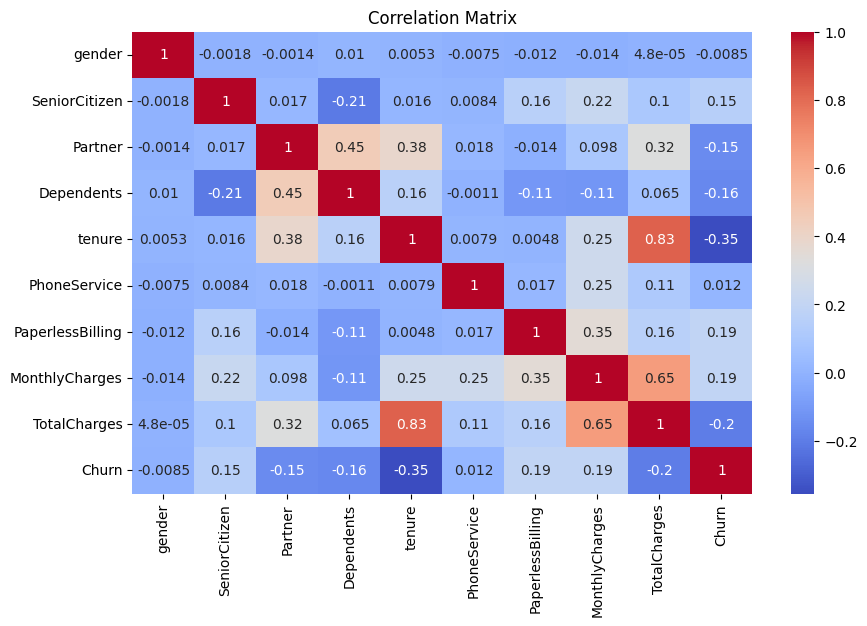

In [23]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [24]:
# Create Tenure Groups

def tenure_group(tenure):
    if tenure <= 12:
        return "0-12 Months"
    elif tenure <= 24:
        return "12-24 Months"
    elif tenure <= 48:
        return "24-48 Months"
    else:
        return "48+ Months"

df["tenure_group"] = df["tenure"].apply(tenure_group)

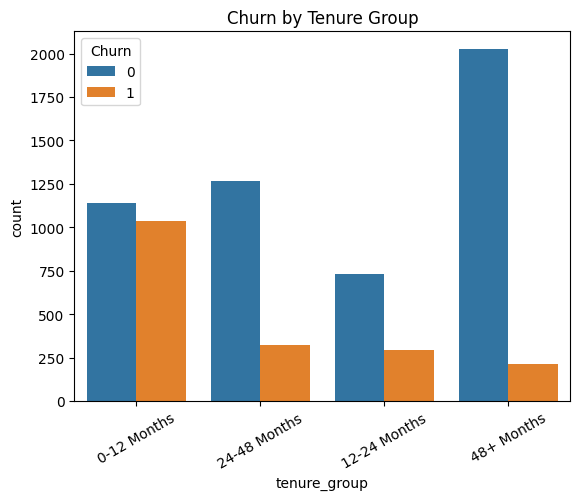

In [26]:
sns.countplot(x="tenure_group", hue="Churn", data=df)
plt.title("Churn by Tenure Group")
plt.xticks(rotation=30)
plt.show()

In [29]:
df["avg_monthly_spend"] = df["TotalCharges"] / df["tenure"]
df["avg_monthly_spend"] = df["avg_monthly_spend"].fillna(0)
df["high_value_customer"] = df["MonthlyCharges"].apply(lambda x: 1 if x > 70 else 0)

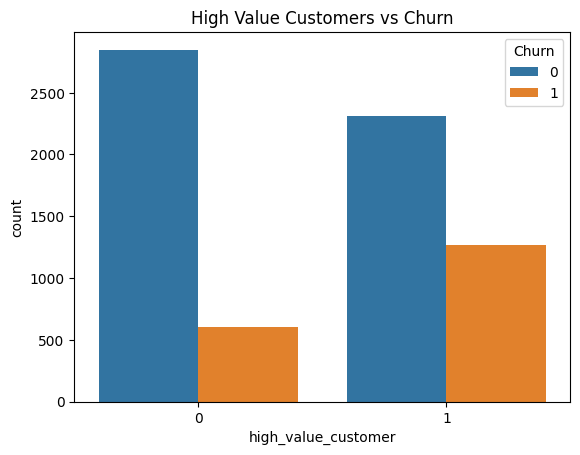

In [30]:
sns.countplot(x="high_value_customer", hue="Churn", data=df)
plt.title("High Value Customers vs Churn")
plt.show()

In [31]:
# Contract Risk Level

def contract_risk(contract):
    if contract == "Month-to-month":
        return "High Risk"
    elif contract == "One year":
        return "Medium Risk"
    else:
        return "Low Risk"

df["contract_risk"] = df["Contract"].apply(contract_risk)

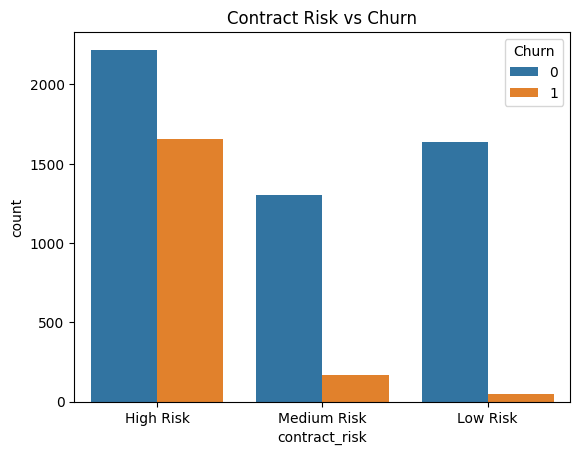

In [32]:
sns.countplot(x="contract_risk", hue="Churn", data=df)
plt.title("Contract Risk vs Churn")
plt.show()